# 04 — Portfolio Optimisation
Using mean-variance optimisation to find the optimal portfolio allocation and plot the efficient frontier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

print(f"Loaded returns: {returns.shape}")
returns.head()

Loaded returns: (1257, 10)


,AAPL,AMZN,BA,BRK-B,GLD,JNJ,JPM,MSFT,PG,XOM
Date,,,,,,,,,,
2020-01-03,-0.009722,-0.012139,-0.001680,-0.009676,0.013269,-0.011578,-0.013196,-0.012452,-0.006726,-0.008040
2020-01-06,0.007968,0.014886,0.002945,0.003581,0.010490,-0.001248,-0.000795,0.002585,0.001387,0.007678
2020-01-07,-0.004703,0.002092,0.010607,-0.004714,0.003935,0.006107,-0.017001,-0.009118,-0.006192,-0.008184
2020-01-08,0.016086,-0.007809,-0.017523,0.000310,-0.007502,-0.000138,0.007801,0.015928,0.004263,-0.015080
2020-01-09,0.021240,0.004799,0.014998,0.011770,-0.005652,0.002967,0.003651,0.012493,0.010938,0.007655


In [3]:
def portfolio_performance(weights, returns):
    port_return = np.dot(weights, returns.mean()) * 252  # annualised
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    sharpe = port_return / port_vol
    return port_return, port_vol, sharpe

In [4]:
n = len(returns.columns)
n_portfolios = 5000

results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n))
    ret, vol, sharpe = portfolio_performance(w, returns)
    results[0, i] = ret
    results[1, i] = vol
    results[2, i] = sharpe
    weights_record.append(w)

results_df = pd.DataFrame(results.T, columns=["Return", "Volatility", "Sharpe"])
print(f"Generated {n_portfolios:,} random portfolios")
results_df.head()

Generated 5,000 random portfolios


,Return,Volatility,Sharpe
0,0.141424,0.180422,0.783852
1,0.115083,0.164325,0.700337
2,0.191512,0.229872,0.833127
3,0.142100,0.140025,1.014817
4,0.115231,0.271216,0.424870


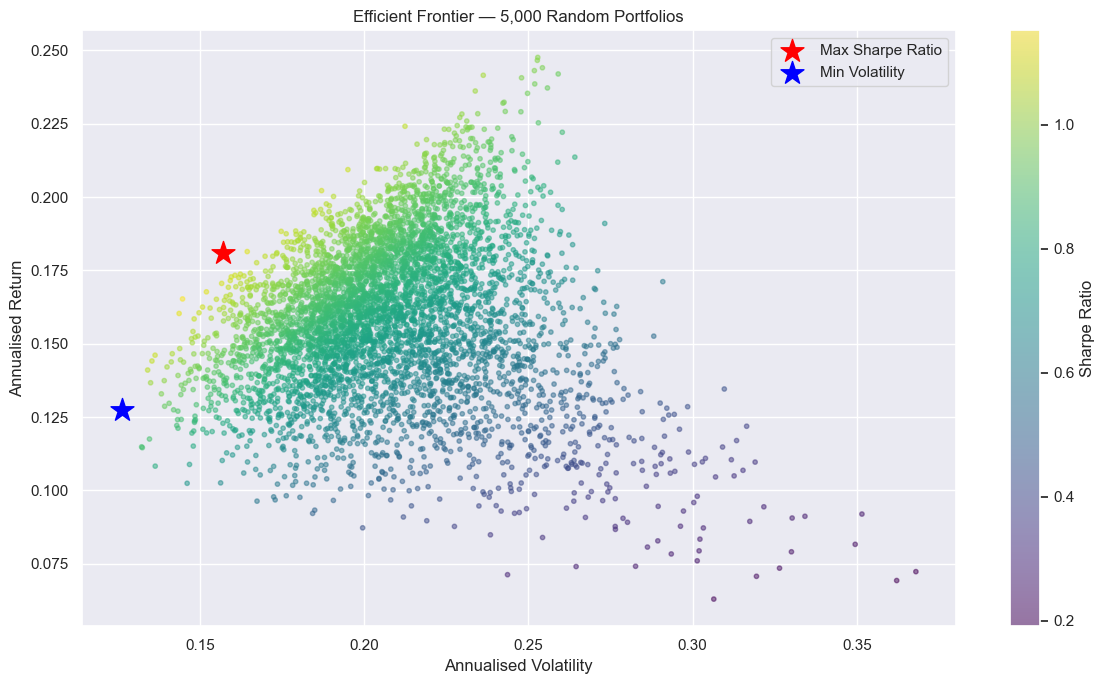

In [5]:
max_sharpe_idx = results_df["Sharpe"].idxmax()
min_vol_idx = results_df["Volatility"].idxmin()

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    results_df["Volatility"], results_df["Return"],
    c=results_df["Sharpe"], cmap="viridis", alpha=0.5, s=10
)
plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(*results_df.loc[max_sharpe_idx, ["Volatility", "Return"]],
            color="red", marker="*", s=300, label="Max Sharpe Ratio")
plt.scatter(*results_df.loc[min_vol_idx, ["Volatility", "Return"]],
            color="blue", marker="*", s=300, label="Min Volatility")

plt.title("Efficient Frontier — 5,000 Random Portfolios")
plt.xlabel("Annualised Volatility")
plt.ylabel("Annualised Return")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/efficient_frontier.png", dpi=150)
plt.show()

In [6]:
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = tuple((0, 1) for _ in range(n))
w0 = np.array([1/n] * n)

# Max Sharpe
def neg_sharpe(w): return -portfolio_performance(w, returns)[2]
opt_sharpe = minimize(neg_sharpe, w0, bounds=bounds, constraints=constraints)

# Min Volatility
def port_vol(w): return portfolio_performance(w, returns)[1]
opt_vol = minimize(port_vol, w0, bounds=bounds, constraints=constraints)

print("=== Max Sharpe Portfolio ===")
for t, w in zip(returns.columns, opt_sharpe.x):
    print(f"  {t:8s}: {w:.2%}")

print("\n=== Min Volatility Portfolio ===")
for t, w in zip(returns.columns, opt_vol.x):
    print(f"  {t:8s}: {w:.2%}")

=== Max Sharpe Portfolio ===
  AAPL    : 23.61%
  AMZN    : 0.88%
  BA      : 0.00%
  BRK-B   : 10.52%
  GLD     : 51.74%
  JNJ     : 0.00%
  JPM     : 2.28%
  MSFT    : 5.11%
  PG      : 0.00%
  XOM     : 5.87%

=== Min Volatility Portfolio ===
  AAPL    : 0.00%
  AMZN    : 1.81%
  BA      : 0.00%
  BRK-B   : 12.77%
  GLD     : 55.81%
  JNJ     : 19.92%
  JPM     : 0.00%
  MSFT    : 0.00%
  PG      : 9.50%
  XOM     : 0.20%


In [7]:
eq_weights = np.array([1/n] * n)

labels = ["Equal Weight", "Max Sharpe", "Min Volatility"]
portfolios = [eq_weights, opt_sharpe.x, opt_vol.x]

summary = []
for label, w in zip(labels, portfolios):
    ret, vol, sharpe = portfolio_performance(w, returns)
    summary.append({
        "Portfolio": label,
        "Ann. Return": f"{ret:.2%}",
        "Ann. Volatility": f"{vol:.2%}",
        "Sharpe Ratio": f"{sharpe:.4f}"
    })

summary_df = pd.DataFrame(summary).set_index("Portfolio")
summary_df.to_csv("../data/portfolio_optimisation_summary.csv")
print("✅ Saved portfolio_optimisation_summary.csv")
summary_df

✅ Saved portfolio_optimisation_summary.csv


,Ann. Return,Ann. Volatility,Sharpe Ratio
Portfolio,,,
Equal Weight,15.94%,19.74%,0.8078
Max Sharpe,17.77%,15.05%,1.1813
Min Volatility,10.93%,12.09%,0.9048
